In [1]:
import os
import sys
import numpy as np
import pandas as pd
import time
from scipy.stats import chi2
import seaborn as sns
import matplotlib.pyplot as plt



In [9]:
print(f"working dir: {os.getcwd()}")
PCs = pd.read_csv(
    'pcs_MAMA_2026.tsv',
    sep=" ",
    header=None, 
    names=['FILE','PC1','PC2','PC3','PC4','PC5','PC6','PC7']
)
PCs.dtypes
PCs['Datasets'] = PCs['FILE'].str.replace(
    r'(\w+)\..+',  # match "data/<name>.<anything>"
    r'\1',              # keep just <name>
    regex=True
)

PCs





working dir: /config/workspace/ws_files/MAMA_2/mama_gp2_non-eur_only/mr-mega_hpm3_run_7pcs


,FILE,PC1,PC2,PC3,PC4,PC5,PC6,PC7,Datasets
0,AAC_R12_imputed_hpm3snplist.tsv,-0.118892,0.011659,-0.002430,0.004392,-0.002825,0.000217,-0.001098,AAC_R12_imputed_hpm3snplist
1,AFR_R12_imputed_hpm3snplist.tsv,-0.186295,-0.003483,-0.001460,0.000075,-0.000432,0.000106,0.001082,AFR_R12_imputed_hpm3snplist
2,AJ_R12_imputed_hpm3snplist.tsv,0.045849,0.064358,0.008306,0.016552,0.024547,0.021333,0.006430,AJ_R12_imputed_hpm3snplist
3,AMR_R12_imputed_hpm3snplist.tsv,0.046166,-0.019421,-0.080061,-0.018208,0.005586,0.000732,-0.001547,AMR_R12_imputed_hpm3snplist
4,CAS_R12_imputed_hpm3snplist.tsv,0.044704,-0.031934,0.009245,0.004289,-0.005551,-0.012914,0.022056,CAS_R12_imputed_hpm3snplist
5,EAS_R12_imputed_hpm3snplist.tsv,0.038317,-0.123388,0.019255,0.022119,0.008562,0.004241,-0.009006,EAS_R12_imputed_hpm3snplist
6,FIN_R12_imputed_hpm3snplist.tsv,0.056940,0.046769,-0.003636,0.025383,-0.042712,0.000902,-0.005907,FIN_R12_imputed_hpm3snplist
7,MDE_R12_imputed_hpm3snplist.tsv,0.038972,0.058604,0.015147,0.000589,0.023920,-0.021669,-0.009649,MDE_R12_imputed_hpm3snplist
8,SAS_R12_imputed_hpm3snplist.tsv,0.034239,-0.003164,0.035632,-0.055192,-0.011095,0.007053,-0.002362,SAS_R12_imputed_hpm3snplist


In [10]:
PCs.loc[PCs['Datasets'].isin(['AAC_R12_imputed_hpm3snplist']),'SUPERPOP']='AAC'
PCs.loc[PCs['Datasets'].isin(['AFR_R12_imputed_hpm3snplist']),'SUPERPOP']='AFR'
PCs.loc[PCs['Datasets'].isin(['AJ_R12_imputed_hpm3snplist']),'SUPERPOP']='AJ'
PCs.loc[PCs['Datasets'].isin(['AMR_R12_imputed_hpm3snplist']),'SUPERPOP']='AMR'
PCs.loc[PCs['Datasets'].isin(['CAS_R12_imputed_hpm3snplist']),'SUPERPOP']='CAS'
PCs.loc[PCs['Datasets'].isin(['EAS_R12_imputed_hpm3snplist']),'SUPERPOP']='EAS'
PCs.loc[PCs['Datasets'].isin(['FIN_R12_imputed_hpm3snplist']),'SUPERPOP']='FIN'
PCs.loc[PCs['Datasets'].isin(['MDE_R12_imputed_hpm3snplist']),'SUPERPOP']='MDE'
PCs.loc[PCs['Datasets'].isin(['SAS_R12_imputed_hpm3snplist']),'SUPERPOP']='SAS'


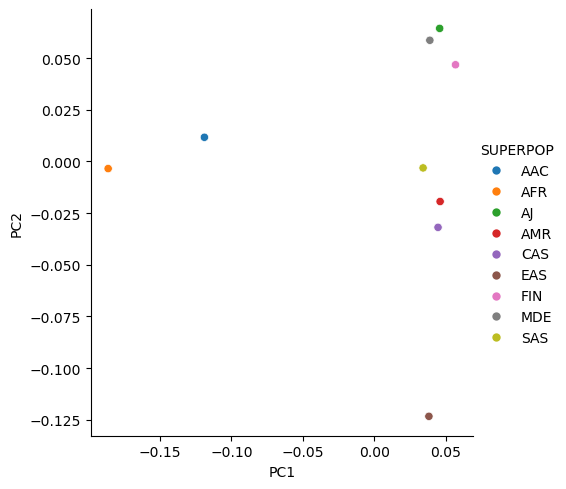

In [13]:
# Apply the default theme
# sns.set_theme()

# PC1 vs PC2
sns.relplot(
    data=PCs,
    x="PC1", y="PC2",
    hue="SUPERPOP",
)

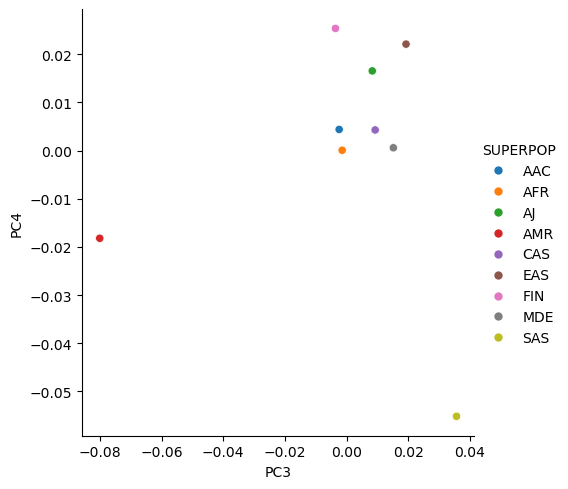

In [14]:
# Apply the default theme
# sns.set_theme()

# PC1 vs PC2
sns.relplot(
    data=PCs,
    x="PC3", y="PC4",
    hue="SUPERPOP",
)

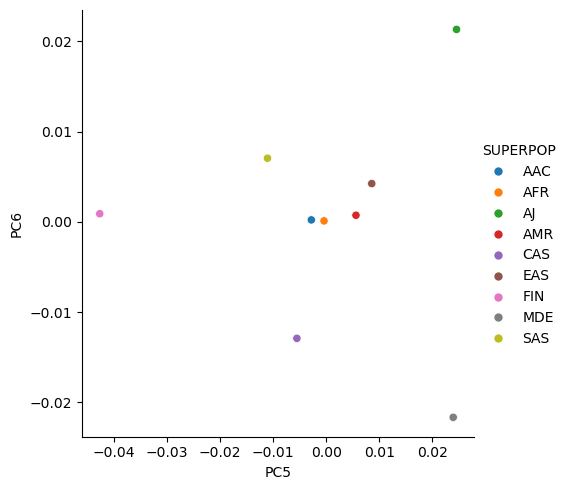

In [15]:
# Apply the default theme
# sns.set_theme()

# PC1 vs PC2
sns.relplot(
    data=PCs,
    x="PC5", y="PC6",
    hue="SUPERPOP",
)

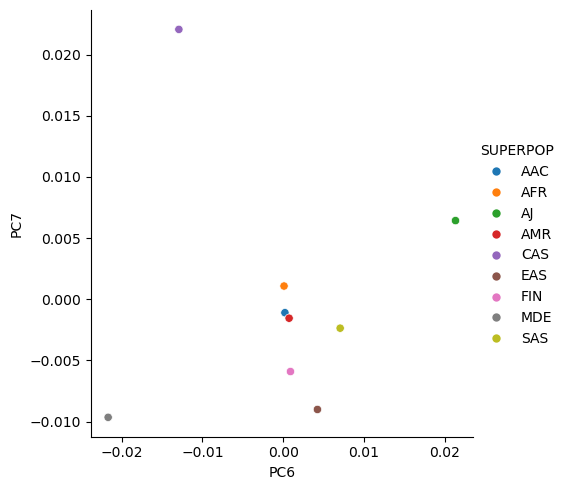

In [16]:
# Apply the default theme
# sns.set_theme()

# PC1 vs PC2
sns.relplot(
    data=PCs,
    x="PC6", y="PC7",
    hue="SUPERPOP",
)

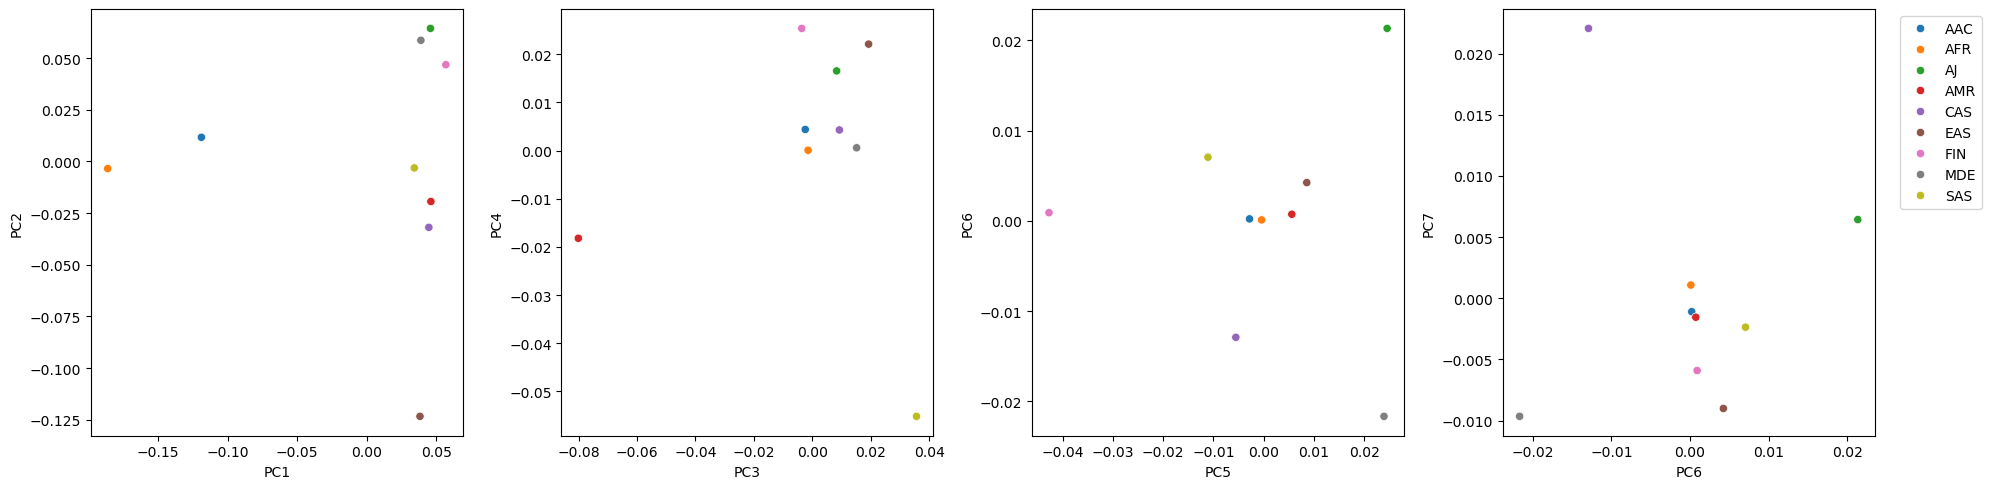

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.scatterplot(data=PCs, x="PC1", y="PC2", hue="SUPERPOP", ax=axes[0], legend=False)
sns.scatterplot(data=PCs, x="PC3", y="PC4", hue="SUPERPOP", ax=axes[1], legend=False)
sns.scatterplot(data=PCs, x="PC5", y="PC6", hue="SUPERPOP", ax=axes[2], legend=False)
sns.scatterplot(data=PCs, x="PC6", y="PC7", hue="SUPERPOP", ax=axes[3], legend=True)

axes[3].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
fig.savefig("PCs_all.png", dpi=300, bbox_inches="tight")
